In [1]:
import re

import numpy as np
import nibabel as nib
import colorcet as cc
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from h5py import File

from nilearn.masking import apply_mask, unmask 
from nilearn.maskers import NiftiLabelsMasker

/mnt/8TB/JC/anaconda3/envs/JCmri/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Helper functions

In [2]:
def compute_cormat(file_name,parcel_img,isort=None):
    
    """
    Extract parcel-wise time series from a 4D neuroimaging dataset and compute
    their Fisher z-transformed correlation matrix.

    The input image is parcellated using a ``NiftiLabelsMasker`` to extract
    one representative time series per parcel. The extracted time series are
    standardized independently, their Pearson correlation matrix is computed,
    and the correlation coefficients are transformed using the Fisher
    z-transform (``arctanh``).

    Parameters
    ----------
    file_name : str or pathlib.Path
        Path to the 4D functional image.
    parcel_img : str, pathlib.Path, or nibabel spatial image
        Parcellation image defining the regions of interest used to extract
        parcel-wise time series.
    isort : array-like of int, optional
        Indices specifying a reordering of the extracted parcel time series
        before computing the correlation matrix. If ``None`` (default), the
        original parcel ordering is preserved.

    Returns
    -------
    signals : ndarray of shape (n_samples, n_parcels)
        Standardized parcel-wise time series extracted from the input image.
    cormat : ndarray of shape (n_parcels, n_parcels)
        Fisher z-transformed Pearson correlation matrix between all pairs of
        parcels.

    Notes
    -----
    The Fisher z-transform is applied using ``numpy.arctanh``. Correlation
    coefficients equal to ±1 produce infinite values; consequently, the
    diagonal of the returned correlation matrix is ``+inf``.
    """
    
    # load the 4D timeseries
    img = nib.load(file_name)
    
    # builds the masker based on the parcellation image
    masker = NiftiLabelsMasker(
        labels_img = parcel_img,
        standardie = "zscore_sample"
    )

    # parcelate the timeseries
    if isort is None:
        signals = standardize(masker.fit_transform(img))
    else:
        signals = standardize(masker.fit_transform(img))[:,isort]

    # returns the Fisher transformed correlation matrix
    return signals, np.arctanh(np.corrcoef(signals, rowvar=False))

def standardize(signals):
    
    """
    Standardize each column of a signal matrix to zero mean and unit variance.

    Each signal (column) is independently standardized by subtracting its
    mean and dividing by its standard deviation. NaN values are ignored when
    computing the mean and standard deviation using ``numpy.nanmean`` and
    ``numpy.nanstd``.

    Parameters
    ----------
    signals : ndarray of shape (n_samples, n_signals)
        Input signal matrix where each column corresponds to a signal and
        each row corresponds to a sample or time point.

    Returns
    -------
    ndarray of shape (n_samples, n_signals)
        Standardized signal matrix with each column having approximately zero
        mean and unit variance (ignoring NaN values).

    Notes
    -----
    If a signal has zero variance, the corresponding standardized values
    will be NaN or infinite due to division by zero.
    """
    
    return (
        signals - np.nanmean(signals, axis=0)
    ) / np.nanstd(signals, axis=0)

def diplay_img(template_img, img, xylim = [25,-25,45,-25], nb_lin = 3, nb_col = 3, slice_ids = None, vmin = -0.3, vmax = 0.3):
    
    """
    Display selected coronal slices of a volumetric image overlaid on an
    anatomical template.

    The template image is displayed in grayscale, while the input image is
    overlaid using a diverging colormap. Voxels with a value of zero are
    rendered transparent. By default, slices are sampled uniformly along the
    third dimension of the volume.

    Parameters
    ----------
    template_img : nibabel.spatialimages.SpatialImage
        Anatomical reference image displayed as the grayscale background.
    img : nibabel.spatialimages.SpatialImage
        Volumetric image to overlay on the anatomical template.
    xylim : list of int, optional
        Cropping bounds of the displayed field of view in voxel coordinates,
        given as ``[xmin, xmax, ymin, ymax]``. Negative indices follow the
        usual NumPy indexing convention. Default is ``[25, -25, 45, -25]``.
    nb_lin : int, optional
        Number of subplot rows. Default is 3.
    nb_col : int, optional
        Number of subplot columns. Default is 3.
    slice_ids : array-like of int, optional
        Indices of the slices to display along the third dimension. If
        ``None`` (default), ``nb_lin * nb_col`` slices are sampled uniformly
        throughout the volume.
    vmin : float, optional
        Lower bound of the overlay colormap. Default is -0.3.
    vmax : float, optional
        Upper bound of the overlay colormap. Default is 0.3.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    ax : ndarray of matplotlib.axes.Axes
        Array of subplot axes displaying the selected slices.

    Notes
    -----
    The overlay is displayed using the ``CET_D1`` colormap from
    ``colorcet``. Voxels with a value of zero are made transparent, while
    non-zero voxels are displayed with a constant opacity of 0.7.
    """
    
    [X,Y,Z] = template_img.shape
    
    if slice_ids is None:
        
        slice_ids = np.linspace(3,Z-2,nb_lin*nb_col).astype(int)
    
    fig, ax = plt.subplots(nb_lin, nb_col, figsize = (2*nb_col, 1.5*nb_lin), dpi = 200, facecolor = 'k')
    
    for slice_id, axi in zip(slice_ids, ax.flatten()):
        
        img_2_display = template_img.get_fdata()[xylim[0]:xylim[1],xylim[2]:xylim[3],slice_id]
        
        axi.imshow(np.rot90(img_2_display), cmap = 'Greys_r')
        
        img_2_display = img.get_fdata()[xylim[0]:xylim[1],xylim[2]:xylim[3],slice_id]
        alpha = 0.7*(abs(img_2_display)>0)
        
        axi.imshow(np.rot90(img_2_display), cmap = cc.cm['CET_D1'], vmin = vmin, vmax = vmax, alpha = np.rot90(alpha))
        axi.axis('off')
        
    plt.tight_layout()
        
    return fig, ax

# Parameters

In [7]:
# edit to match your data structure

# data folder
sourcedata = Path('/mnt/8TB/JC/3_Trash/2026-07-17_Trang-Anh-Nghiem/')

template_name = Path('Params/templates/chd8_functional_template_sk.nii.gz')
template_img = nib.load(template_name)
[X,Y,Z] = template_img.shape

mask_name = Path('Params/templates/chd8_functional_template_mask.nii.gz')
mask_img = nib.load(mask_name)

parcel_name = Path('Params/parcellation/source-gozzilab_space-chd8Native_desc-chd8NativeParcellationUnilateralDefaultN53_res-600umx230umx230um_feature.nii.gz')
parcel_img = nib.load(parcel_name)
parcel_metadata = Path('Params/parcellation/source-gozzilab_space-chd8Native_desc-chd8NativeParcellationUnilateralDefaultN53_res-600umx230umx230um_feature.csv')
parcel_df = pd.read_csv(parcel_metadata, index_col=0)

nb_parcels = len(parcel_df)

print(parcel_df.head())

      acro  allen_ids  parcel_ids network  side
0      FRP        184           1     LCN  left
1      MOp        985           2     LCN  left
2      MOs        993           3  DMNmid  left
3    SSp-n        353           4     LCN  left
4  SSp-bfd        329           5  DMNpln  left


# Data

In [8]:
root_path = sourcedata / Path('1_data/00_bold-smoothed/')

root_dir = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files:\n\n')

for x in root_dir:
    
    print(x.name)

We found 10 files:


ag191108a_aw4_re_5_ts_smoothed.nii.gz
ag191218a_aw5_re_5_ts_smoothed.nii.gz
ag191218b_aw5_re_5_ts_smoothed.nii.gz
ag191218c_aw5_re_5_ts_smoothed.nii.gz
ag191218d_aw5_re_5_ts_smoothed.nii.gz
ag191218e_aw5_re_5_ts_smoothed.nii.gz
ag191218f_aw5_re_5_ts_smoothed.nii.gz
ag200610a_awCort_5_rs1_smoothed.nii.gz
ag200610b_awCort_5_rs1_smoothed.nii.gz
ag200610c_awCort_5_rs1_smoothed.nii.gz


# Parcellating timeseries

## Parameters

In [38]:
# edit to match your data structure

save_dir_ts = sourcedata / Path('1_data/01_bold-parcellated/')
save_dir_cormat = sourcedata / Path('1_data/02_FC-matrices/')

## Loop

In [39]:
for file_name in tqdm(root_dir):

    signals, correlation_matrix = compute_cormat(
        file_name,
        parcel_img
    )
    
    # Timeseries
    
    save_name = save_dir_ts / (file_name.name.split('.nii.gz')[0] + '_ts.h5')
    
    with File(save_name, 'w') as f:
        
        f.create_dataset('/bold_ts', data = signals)
        
    # correlation matrix
    
    save_name = save_dir_cormat / (file_name.name.split('.nii.gz')[0] + '_cormat.h5')
    
    with File(save_name, 'w') as f:
        
        f.create_dataset('/correlation_matrix', data = correlation_matrix)

  0%|                                                    | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_299346/3458781815.py:56: RuntimeWarning: divide by zero encountered in arctanh
  return signals, np.arctanh(np.corrcoef(signals, rowvar=False))
100%|███████████████████████████████████████████| 10/10 [04:25<00:00, 26.53s/it]


# FC analysis

Example script for reading data. Computing population average FC and Fisher inverse transform.

## Parameters

In [9]:
root_path = Path('1_data/02_FC-matrices/')
root_dir = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^.*cormat.*$', x.name)])

print(f'We found {len(root_dir)} files:\n\n')

for x in root_dir:
    
    print(x.name)

We found 10 files:


ag191108a_aw4_re_5_ts_smoothed_cormat.h5
ag191218a_aw5_re_5_ts_smoothed_cormat.h5
ag191218b_aw5_re_5_ts_smoothed_cormat.h5
ag191218c_aw5_re_5_ts_smoothed_cormat.h5
ag191218d_aw5_re_5_ts_smoothed_cormat.h5
ag191218e_aw5_re_5_ts_smoothed_cormat.h5
ag191218f_aw5_re_5_ts_smoothed_cormat.h5
ag200610a_awCort_5_rs1_smoothed_cormat.h5
ag200610b_awCort_5_rs1_smoothed_cormat.h5
ag200610c_awCort_5_rs1_smoothed_cormat.h5


## load

In [44]:
cormat_list = []

for file_name in tqdm(root_dir):

    # load the .h5 file
    with File(file_name, 'r') as f:
        correlation_matrix = f['correlation_matrix'][:]
        
    # store correlation matrices in a list
    cormat_list.append(correlation_matrix)

100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 867.06it/s]


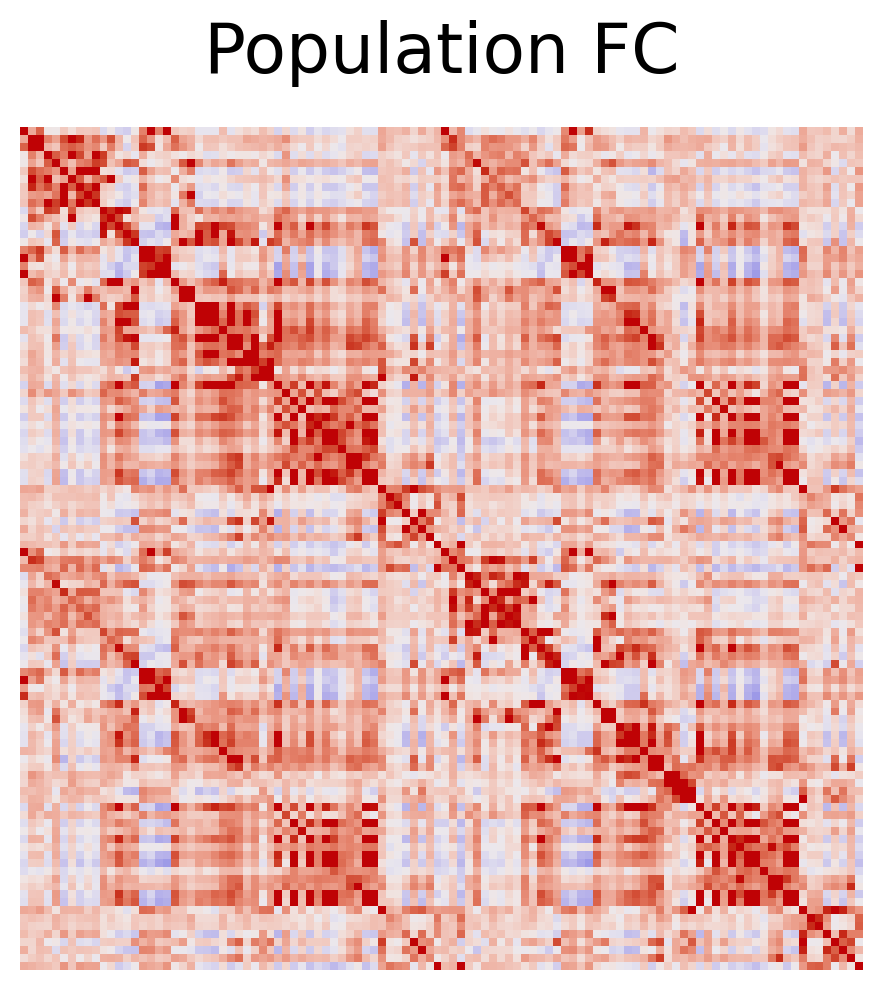

In [47]:
# computes the average matrix in the fisher space and inverse transform as r values
avg_FC_matrix = np.tanh(np.nanmean(cormat_list, axis = 0))

# plot 

fig, ax = plt.subplots(1,1,figsize = (5,5), dpi = 200)

plt.imshow(avg_FC_matrix, cmap = cc.cm['CET_D1'], vmin = -0.5, vmax = 0.5)
plt.axis('off')
plt.suptitle('Population FC', fontsize = 25)
plt.tight_layout()

# SFC analysis

Example script for loading SC matrix, two options:

- reconstructing from Allen output
- loading from h5 file

And computing SC to FC relationship:

- at the network level
- at the regional level

## Loads SC

### From Allen

To load the connectome as given by `generate_structural_connectivity_matrix_from_allen_parcels.py` encoded as a right matrix (Ipsilateral connectivity) and a left matrix (Contralateral connectivity). Default unit is normalize connection density (ncd).

Final SC matrix is:

| Right    | Left      |
|----------|----------|
| Left    | Right      |

**N.B.** requires the data repository

In [49]:
# Loading matrices

# Paths to edit to match local environment
right_name = sourcedata / Path('2_SC/2026-07-17_TrangAnh-Nghiem-SC/SC_matrix/ncd_right_hem.txt')
left_name = sourcedata / Path('2_SC/2026-07-17_TrangAnh-Nghiem-SC/SC_matrix/ncd_left_hem.txt')

# constructing the matrix

sc_list = []

with open(right_name, 'r') as f:
    
    for row in f.readlines():
        
        sc_list.append([float(x) for x in row.split('\n')[0].split('\t')])
        
sc_data_right = np.array(sc_list)

sc_list = []

with open(left_name, 'r') as f:
    
    for row in f.readlines():
        
        sc_list.append([float(x) for x in row.split('\n')[0].split('\t')])
        
sc_data_left = np.array(sc_list)

# sc

sc = np.block(
    [[sc_data_right, sc_data_left], [sc_data_left, sc_data_right]]
)

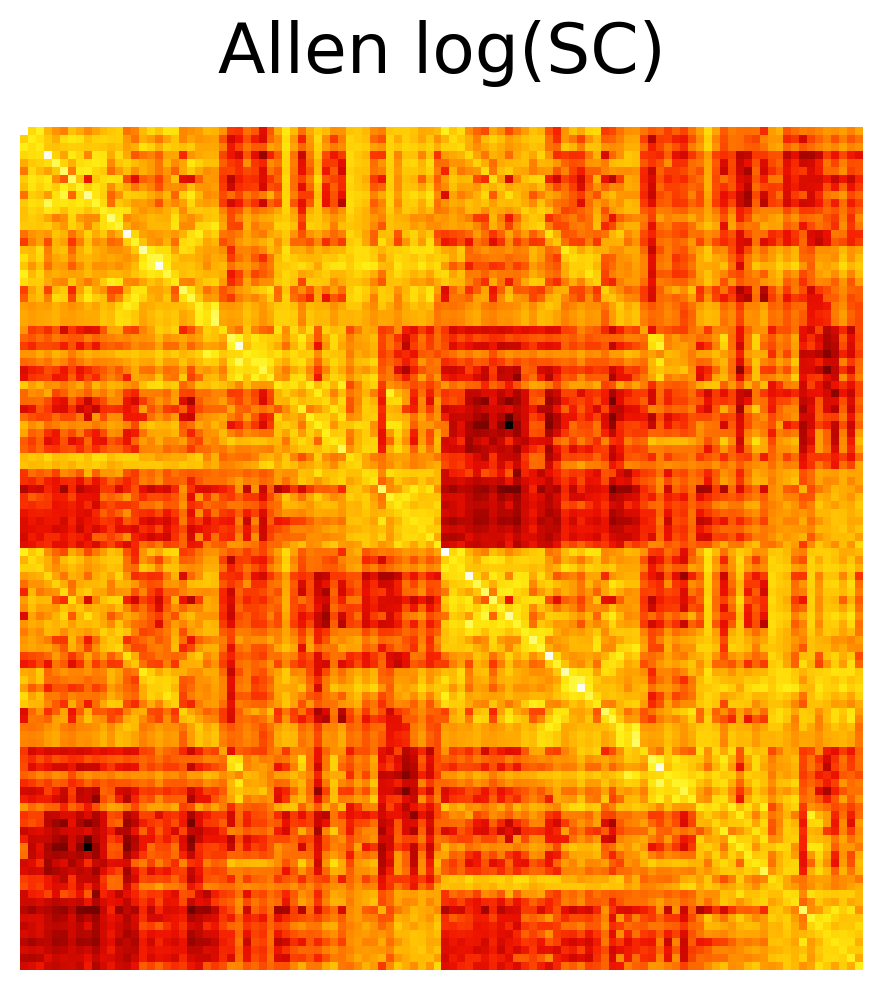

In [51]:
# plot 

fig, ax = plt.subplots(1,1,figsize = (5,5), dpi = 200)

# display in log scale 
plt.imshow(np.log10(sc), cmap = cc.cm['fire'])
plt.axis('off')
plt.suptitle('Allen log(SC)', fontsize = 25)
plt.tight_layout()

In [ ]:
# optional saving the SC matrix

# edit to match your data structure
save_name = sourcedata / Path('2_SC/2026-07-17_TrangAnh-Nghiem-SC/SC_matrix/00_full-SC-matrix_ncd.h5')

with File(save_name, 'w') as f:
    
    f.create_dataset('/sc_matrix', data = sc)

### From h5

If the matrix is already built one can load directly the consolidated matrix.

In [16]:
# edit to match your data structure
file_name = Path('Params/connectome/00_full-SC-matrix_ncd.h5')

with File(file_name, 'r') as f:
    
    sc = f['/sc_matrix'][:]

## SFC

For SFC analysis connectivity matrices are normalised as follow to maximize gaussianity:
- SC is log transformed
- FC is fisher transformed
Both are standardised (demean + unite variance) for display (correlation is normalised by construct)

### Network level

All non diagonal edges are used to compute the correlation.

In [75]:
edge_mask = (1-np.diag(np.ones(nb_parcels)))>0

sc_norm = np.log(sc)
sc_norm = (sc_norm-np.nanmean(sc_norm[edge_mask]))/np.nanstd(sc_norm[edge_mask])
fc_norm = np.arctanh(avg_FC_matrix)
fc_norm = (fc_norm-np.nanmean(fc_norm[edge_mask]))/np.nanstd(fc_norm[edge_mask])

sc_norm[np.isinf(sc_norm) | np.isnan(sc_norm)] = 0
fc_norm[np.isinf(fc_norm) | np.isnan(fc_norm)] = 0

/tmp/ipykernel_299346/1231421463.py:5: RuntimeWarning: divide by zero encountered in arctanh
  fc_norm = np.arctanh(avg_FC_matrix)


<Axes: ylabel='Count'>

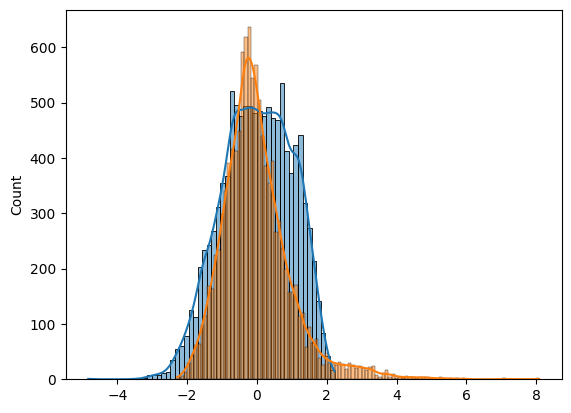

In [76]:
sns.histplot(sc_norm[edge_mask], kde = True, alpha = 0.5)
sns.histplot(fc_norm[edge_mask], kde = True, alpha = 0.5)

In [77]:
print(f'Network SFC = {100*np.corrcoef(sc_norm[edge_mask], fc_norm[edge_mask])[0,1]:.2f}%')

Network SFC = 28.51%


### Parcel level

In [84]:
correlation_vector = [np.corrcoef(x,y)[0,1] for x,y in zip(sc_norm, fc_norm)]

sfc_data = np.zeros(parcel_img.shape)

for idx in range(nb_parcels):
    
    sfc_data[parcel_img.get_fdata() == idx+1] = correlation_vector[idx]
    
sfc_img = nib.Nifti1Image(
    sfc_data,
    affine = parcel_img.affine
)

(<Figure size 1200x900 with 9 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

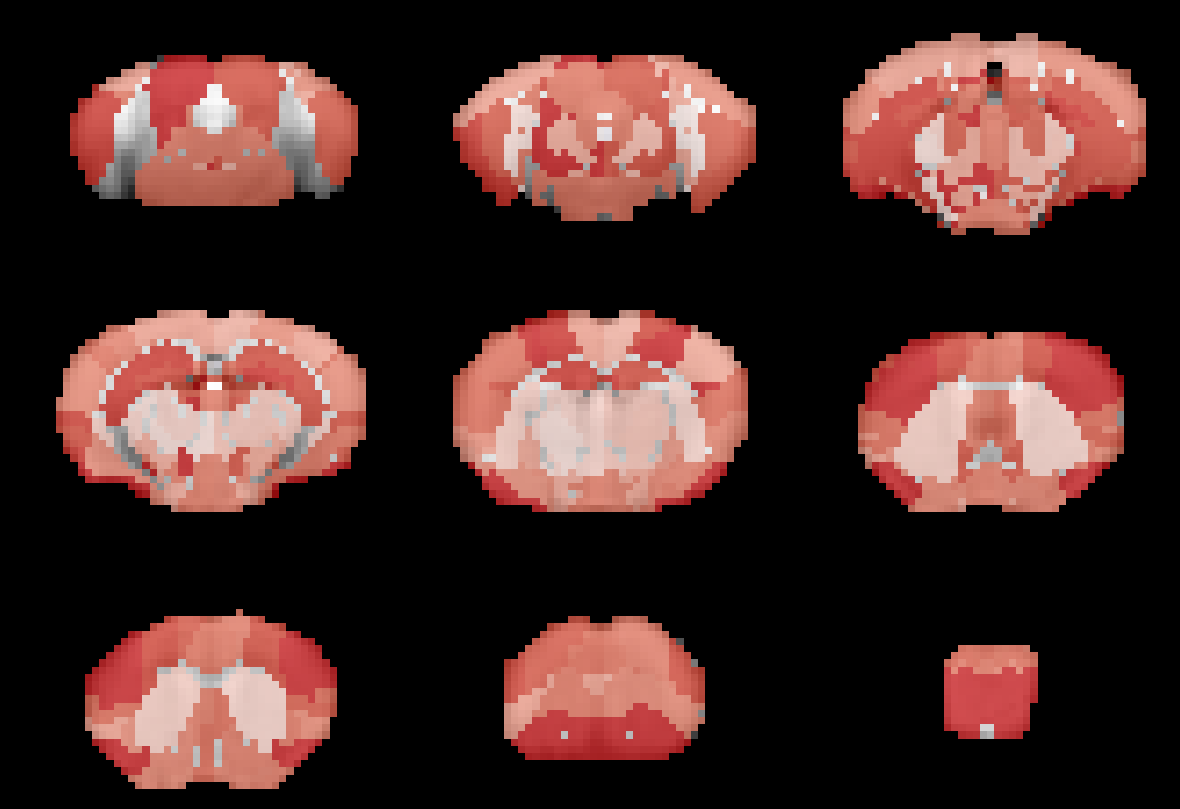

In [97]:
diplay_img(template_img, sfc_img, vmin = -0.5, vmax = 0.5)